# FID score:
The Frechet Inception Distance (FID) is a metric used to evaluate the quality of generated images by comparing them to real images. It works by passing both real and generated images through a pretrained Inception network to extract high-level feature representations. FID then models these features as multivariate Gaussian distributions and computes the Fréchet distance between them. A lower FID score indicates that the generated images are more similar to real images in terms of both visual quality and diversity.

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))
%load_ext autoreload
%autoreload 2

In [2]:
import cv2
import numpy as np
import torch
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from eval.utils import RGBFIDDataset, compute_fid
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

from torchmetrics.image.fid import FrechetInceptionDistance
from torch.utils.data import Dataset, DataLoader
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data formating for FID:

In [3]:
first_rgb = Image.open("/scratch/tmaillar/rgb/train/point_32_view_0_domain_rgb.png").convert("RGB")
second_rgb = Image.open("/scratch/tmaillar/rgb/train/point_40_view_0_domain_rgb.png").convert("RGB")

crop_settings_0 = np.load("/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy")

def format_image_for_FID(path, crop_settings, aug_idx = 1, device="cuda"):
    img = Image.open(path).convert("RGB")
    
    x1, y1, x2, y2, flip = crop_settings[aug_idx]
    top, left, h, w = y1, x1, (y2 - y1), (x2 - x1)
    
    cropped = TF.crop(img, top, left, h, w)
    resized = cropped.resize((256, 256), resample=Image.BILINEAR)
    
    if flip:
        resized = TF.hflip(resized)
        
    img = np.array(resized)
    img = torch.from_numpy(img).permute(2,0,1).byte()
    
    resized.show()

    return img.to(device).unsqueeze(0)

## Test with same Data:
**FID score must be ~0**

In [33]:
crop_settings_01_pth = "/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy"
real_data_pth = "/scratch/tmaillar/rgb/train"
fake_data_pth = real_data_pth

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score = {score}")

Fake images:  20%|█████████████▍                                                     | 313/1563 [00:24<01:35, 13.02it/s]


FID score = -1.6058265828178264e-11


## FID comparaison scene_desc->RGB VS scene_desc->Canny->RGB

scene_desc->RGB:

In [4]:
crop_settings_01_pth = "/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy"
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/scene_desc_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for scene_desc->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 38.22it/s]


FID score for scene_desc->RGB = 113.3284912109375


scene_desc->Canny->RGB:

In [5]:
crop_settings_01_pth = "/work/com-304/datasets/clevr_com_304/train/crop_settings/00001.npy"
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/scene_desc_to_canny_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for scene_desc->canny->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 38.18it/s]


FID score for scene_desc->RGB = 111.37319946289062


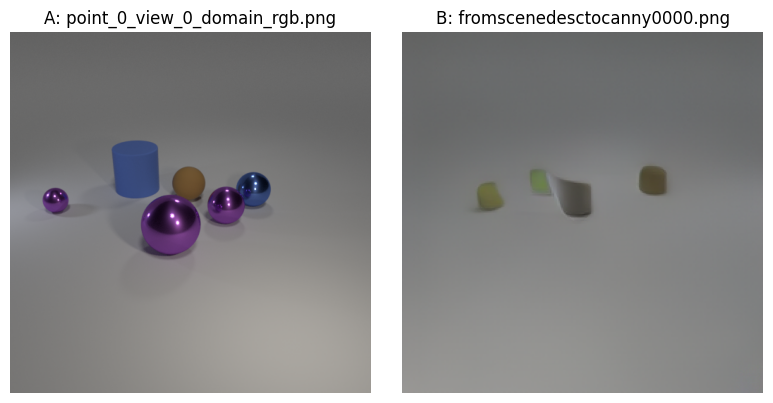

In [13]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

dir_a = Path(real_data_pth)
dir_b = Path(fake_data_pth)

files_a = sorted(list(dir_a.glob("*.png")))
files_b = sorted(list(dir_b.glob("*.png")))

n = 1

for i in range(n):
    img_a = Image.open(files_a[i])
    img_b = Image.open(files_b[i])

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.imshow(img_a)
    plt.title(f"A: {files_a[i].name}")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img_b)
    plt.title(f"B: {files_b[i].name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

### FID comparaison depth->RGB VS 4depth->Canny->RGB

In [22]:
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/depth_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for depth->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 37.17it/s]


FID score for depth->RGB = 35.150428771972656


In [23]:
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/depth_to_canny_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for depth->canny->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 35.49it/s]


FID score for depth->canny->RGB = 39.54645919799805


### FID comparaison depth->RGB VS Canny->RGB VS normal->RGB VS scene_desc->RGB

## Got :
- depth->RGB = 35.150428771972656
- scene_desc->RGB = 113.3284912109375


In [24]:
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/canny_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for canny->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 38.39it/s]


FID score for canny->RGB = 51.35471725463867


In [25]:
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/normal_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for normal->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 38.87it/s]


FID score for normal->RGB = 34.25809097290039


### FID normal->canny->rgb

In [26]:
real_data_pth = "/scratch/tmaillar/rgb/test"
fake_data_pth = "/scratch/deriaz/normal_to_canny_to_rgb"

score = compute_fid(
    real_dir=real_data_pth,
    fake_dir=fake_data_pth,
    crop_settings_dir=None,
    batch_size=32,
    device=device,
    image_size=256,
    num_workers=4,
    max_images=10000
)

print(f"FID score for normal->canny->RGB = {score}")

Fake images: 100%|████████████████████████████████████████████████████████████████████| 157/157 [00:04<00:00, 36.83it/s]


FID score for normal->canny->RGB = 39.65471267700195
